# Lab01S03 — Análise e Visualização de Dados
## Características dos 1.000 Repositórios Mais Populares do GitHub

| RQ | Pergunta | Métrica |
|:--:|----------|--------|
| 01 | Sistemas populares são maduros/antigos? | Idade do repositório |
| 02 | Recebem muita contribuição externa? | Total de PRs aceitas |
| 03 | Lançam releases com frequência? | Total de releases |
| 04 | São atualizados com frequência? | Tempo até última atualização |
| 05 | São escritos nas linguagens mais populares? | Linguagem primária |
| 06 | Possuem alto percentual de issues fechadas? | Razão issues fechadas / total |
| 07 | Sistemas em linguagens populares recebem mais contribuição, releases e updates? | PRs, releases e updates por grupo de linguagem |

## 1. Setup e Carregamento dos Dados

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import glob
import os
from datetime import datetime

# Estilo dos gráficos
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.bbox"] = "tight"

CHARTS_DIR = "charts"
REPORTS_DIR = "reports"
os.makedirs(CHARTS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

LINGUAGENS_POPULARES = ["TypeScript", "Python", "JavaScript"]

print("Setup OK")

Setup OK


In [29]:
# Carrega o dataset mais recente da Sprint-02
json_files = sorted(glob.glob("data/repos_lab01_s02*.json"), reverse=True)
csv_files = sorted(glob.glob("data/repos_lab01_s02*.csv"), reverse=True)

if json_files:
    latest = json_files[0]
    df = pd.read_json(latest, orient="records", convert_dates=["criado_em", "atualizado_em"])
    print(f"Carregado (JSON): {latest}")
elif csv_files:
    latest = csv_files[0]
    df = pd.read_csv(latest, parse_dates=["criado_em", "atualizado_em"])
    print(f"Carregado (CSV): {latest}")
else:
    raise FileNotFoundError("Nenhum arquivo repos_lab01_s02* encontrado em ../Sprint-02/data/!")

print(f"Shape: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(f"Colunas: {list(df.columns)}")

Carregado (JSON): data\repos_lab01_s0220260306_175638.json
Shape: 1000 linhas x 12 colunas
Colunas: ['nome', 'estrelas', 'criado_em', 'idade_dias', 'atualizado_em', 'dias_desde_update', 'linguagem', 'prs_aceitas', 'releases', 'total_issues', 'issues_fechadas', 'razao_fechadas']


In [30]:
# Colunas derivadas
df["idade_anos"] = df["idade_dias"] / 365.25
df["linguagem_clean"] = df["linguagem"].fillna("Sem linguagem")
df["grupo_lang"] = df["linguagem"].apply(
    lambda x: "Top 3 Octoverse" if x in LINGUAGENS_POPULARES else ("Sem linguagem" if pd.isna(x) else "Outras")
)

print(f"Repositórios carregados: {len(df)}")
df.head()

Repositórios carregados: 1000


,nome,estrelas,criado_em,idade_dias,atualizado_em,dias_desde_update,linguagem,prs_aceitas,releases,total_issues,issues_fechadas,razao_fechadas,idade_anos,linguagem_clean,grupo_lang
0,codecrafters-io/build-your-own-x,472883,2018-05-09 12:03:18+00:00,2858,2026-03-06 20:23:59+00:00,0,Markdown,155,0,888,653,0.7354,7.824778,Markdown,Outras
1,sindresorhus/awesome,443097,2014-07-11 13:42:37+00:00,4256,2026-03-06 20:35:49+00:00,0,None,694,0,365,349,0.9562,11.652293,Sem linguagem,Sem linguagem
2,freeCodeCamp/freeCodeCamp,437844,2014-12-24 17:49:19+00:00,4090,2026-03-06 20:14:08+00:00,0,TypeScript,27781,0,21157,20983,0.9918,11.197810,TypeScript,Top 3 Octoverse
3,public-apis/public-apis,404753,2016-03-20 23:49:42+00:00,3637,2026-03-06 20:33:07+00:00,0,Python,1872,0,839,833,0.9928,9.957563,Python,Top 3 Octoverse
4,EbookFoundation/free-programming-books,383678,2013-10-11 06:50:37+00:00,4529,2026-03-06 20:17:20+00:00,0,Python,7333,0,1264,1228,0.9715,12.399726,Python,Top 3 Octoverse


## 2. Análise Exploratória Geral (EDA)

In [31]:
cols_numericas = ["estrelas", "idade_dias", "prs_aceitas", "releases", "dias_desde_update", "total_issues", "issues_fechadas", "razao_fechadas"]
df[cols_numericas].describe().round(2)

,estrelas,idade_dias,prs_aceitas,releases,dias_desde_update,total_issues,issues_fechadas,razao_fechadas
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,58047.52,2987.98,3954.17,120.50,0.02,5003.91,4357.96,0.77
std,46453.37,1494.14,9869.04,199.32,0.14,11879.96,10703.98,0.26
min,29594.00,33.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,34344.00,1829.00,173.50,0.00,0.00,396.50,249.50,0.68
50%,42956.00,3061.00,743.00,40.00,0.00,1740.00,1399.50,0.87
75%,62580.50,4167.50,3197.75,143.50,0.00,5267.00,4533.50,0.96
max,472883.00,6538.00,94722.00,1000.00,1.00,232359.00,218871.00,1.00


In [32]:
# Resumo das medianas por RQ
medianas = pd.DataFrame({
    "RQ": ["RQ01", "RQ02", "RQ03", "RQ04", "RQ06"],
    "Métrica": ["Idade (dias)", "PRs aceitas", "Releases", "Dias desde update", "Razão issues fechadas"],
    "Mediana": [
        df["idade_dias"].median(),
        df["prs_aceitas"].median(),
        df["releases"].median(),
        df["dias_desde_update"].median(),
        df["razao_fechadas"].median(),
    ]
}).set_index("RQ")

medianas

,Métrica,Mediana
RQ,,
RQ01,Idade (dias),3061.0000
RQ02,PRs aceitas,743.0000
RQ03,Releases,40.0000
RQ04,Dias desde update,0.0000
RQ06,Razão issues fechadas,0.8676


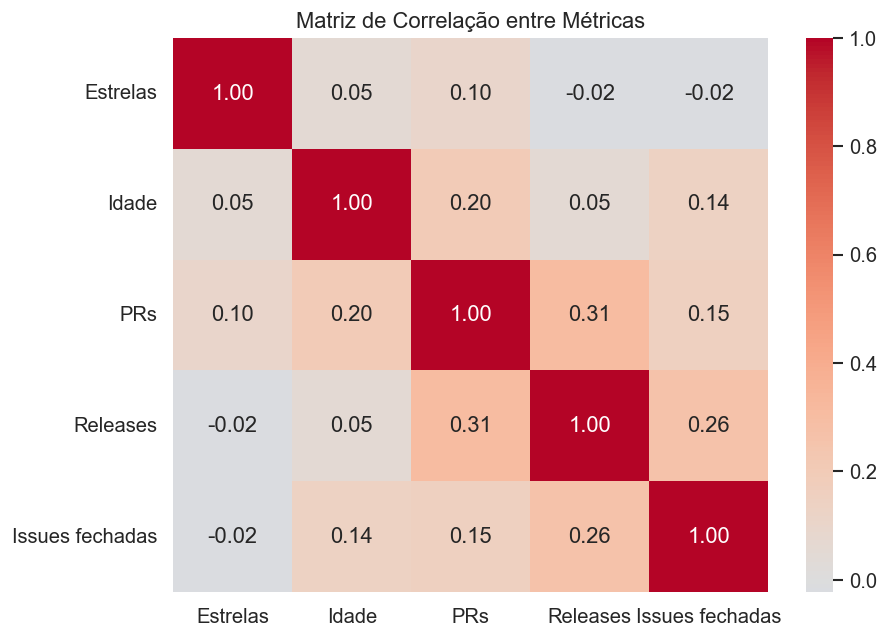

In [33]:
# Matriz de correlação entre as métricas numéricas
cols_corr = ["estrelas", "idade_dias", "prs_aceitas", "releases", "razao_fechadas"]
corr = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
            xticklabels=["Estrelas", "Idade", "PRs", "Releases", "Issues fechadas"],
            yticklabels=["Estrelas", "Idade", "PRs", "Releases", "Issues fechadas"])
ax.set_title("Matriz de Correlação entre Métricas")
fig.savefig(f"{CHARTS_DIR}/00_correlacao.png")
plt.show()

## 3. RQ01 — Sistemas populares são maduros/antigos?

**Hipótese:** A mediana de idade dos repositórios populares é de **pelo menos 5 anos** (1.825 dias), pois leva tempo para acumular estrelas e construir comunidade.

In [34]:
print("=== RQ01 — Idade dos repositórios ===")
print(f"Média:   {df['idade_anos'].mean():.1f} anos ({df['idade_dias'].mean():.0f} dias)")
print(f"Mediana: {df['idade_anos'].median():.1f} anos ({df['idade_dias'].median():.0f} dias)")
print(f"Mínimo:  {df['idade_anos'].min():.1f} anos ({df['idade_dias'].min():.0f} dias)")
print(f"Máximo:  {df['idade_anos'].max():.1f} anos ({df['idade_dias'].max():.0f} dias)")
print(f"Desvio padrão: {df['idade_anos'].std():.1f} anos")
print(f"\nRepos com mais de 5 anos: {(df['idade_anos'] > 5).sum()} ({(df['idade_anos'] > 5).mean()*100:.1f}%)")
print(f"Repos com mais de 3 anos: {(df['idade_anos'] > 3).sum()} ({(df['idade_anos'] > 3).mean()*100:.1f}%)")
print(f"Repos com menos de 1 ano: {(df['idade_anos'] < 1).sum()} ({(df['idade_anos'] < 1).mean()*100:.1f}%)")

=== RQ01 — Idade dos repositórios ===
Média:   8.2 anos (2988 dias)
Mediana: 8.4 anos (3061 dias)
Mínimo:  0.1 anos (33 dias)
Máximo:  17.9 anos (6538 dias)
Desvio padrão: 4.1 anos

Repos com mais de 5 anos: 751 (75.1%)
Repos com mais de 3 anos: 850 (85.0%)
Repos com menos de 1 ano: 26 (2.6%)


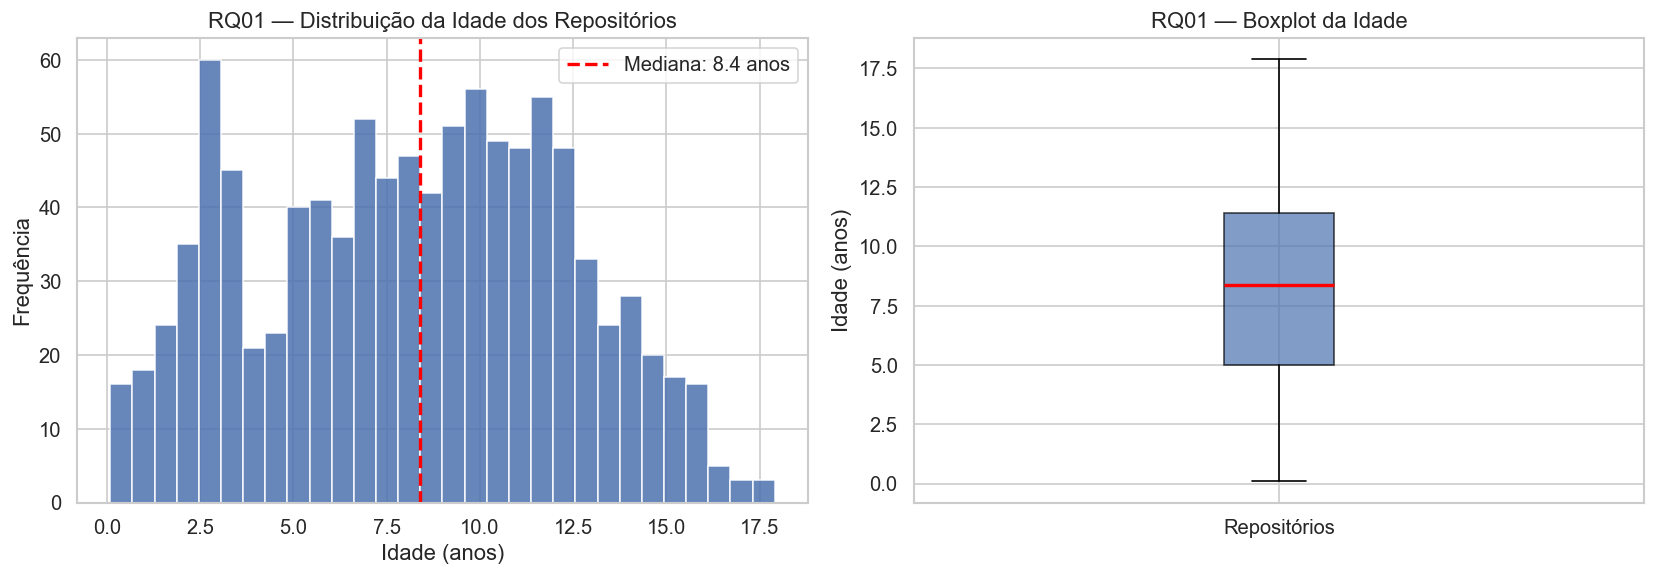

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
ax = axes[0]
ax.hist(df["idade_anos"], bins=30, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.axvline(df["idade_anos"].median(), color="red", linestyle="--", linewidth=2, label=f"Mediana: {df['idade_anos'].median():.1f} anos")
ax.set_xlabel("Idade (anos)")
ax.set_ylabel("Frequência")
ax.set_title("RQ01 — Distribuição da Idade dos Repositórios")
ax.legend()

# Boxplot
ax = axes[1]
bp = ax.boxplot(df["idade_anos"], vert=True, patch_artist=True,
                boxprops=dict(facecolor="#4C72B0", alpha=0.7),
                medianprops=dict(color="red", linewidth=2))
ax.set_ylabel("Idade (anos)")
ax.set_title("RQ01 — Boxplot da Idade")
ax.set_xticklabels(["Repositórios"])

fig.tight_layout()
fig.savefig(f"{CHARTS_DIR}/01_rq01_idade.png")
plt.show()

## 4. RQ02 — Sistemas populares recebem muita contribuição externa?

**Hipótese:** A mediana de PRs aceitas dos repositórios populares é de **pelo menos 500**, já que a alta visibilidade atrai colaboradores.

In [36]:
print("=== RQ02 — Pull Requests Aceitas ===")
print(f"Média:   {df['prs_aceitas'].mean():.0f}")
print(f"Mediana: {df['prs_aceitas'].median():.0f}")
print(f"Mínimo:  {df['prs_aceitas'].min():.0f}")
print(f"Máximo:  {df['prs_aceitas'].max():.0f}")
print(f"Desvio padrão: {df['prs_aceitas'].std():.0f}")
print(f"\nRepos com 0 PRs aceitas: {(df['prs_aceitas'] == 0).sum()}")
print(f"Repos com > 1000 PRs: {(df['prs_aceitas'] > 1000).sum()} ({(df['prs_aceitas'] > 1000).mean()*100:.1f}%)")
print(f"Repos com > 10000 PRs: {(df['prs_aceitas'] > 10000).sum()} ({(df['prs_aceitas'] > 10000).mean()*100:.1f}%)")

=== RQ02 — Pull Requests Aceitas ===
Média:   3954
Mediana: 743
Mínimo:  0
Máximo:  94722
Desvio padrão: 9869

Repos com 0 PRs aceitas: 13
Repos com > 1000 PRs: 435 (43.5%)
Repos com > 10000 PRs: 95 (9.5%)


C:\Users\luizp\AppData\Local\Temp\ipykernel_33696\921627902.py:25: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\luizp\AppData\Local\Temp\ipykernel_33696\921627902.py:25: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\luizp\AppData\Local\Temp\ipykernel_33696\921627902.py:26: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(f"{CHARTS_DIR}/02_rq02_prs.png")
C:\Users\luizp\AppData\Local\Temp\ipykernel_33696\921627902.py:26: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.savefig(f"{CHARTS_DIR}/02_rq02_prs.png")
C:\Users\luizp\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\luizp\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: User

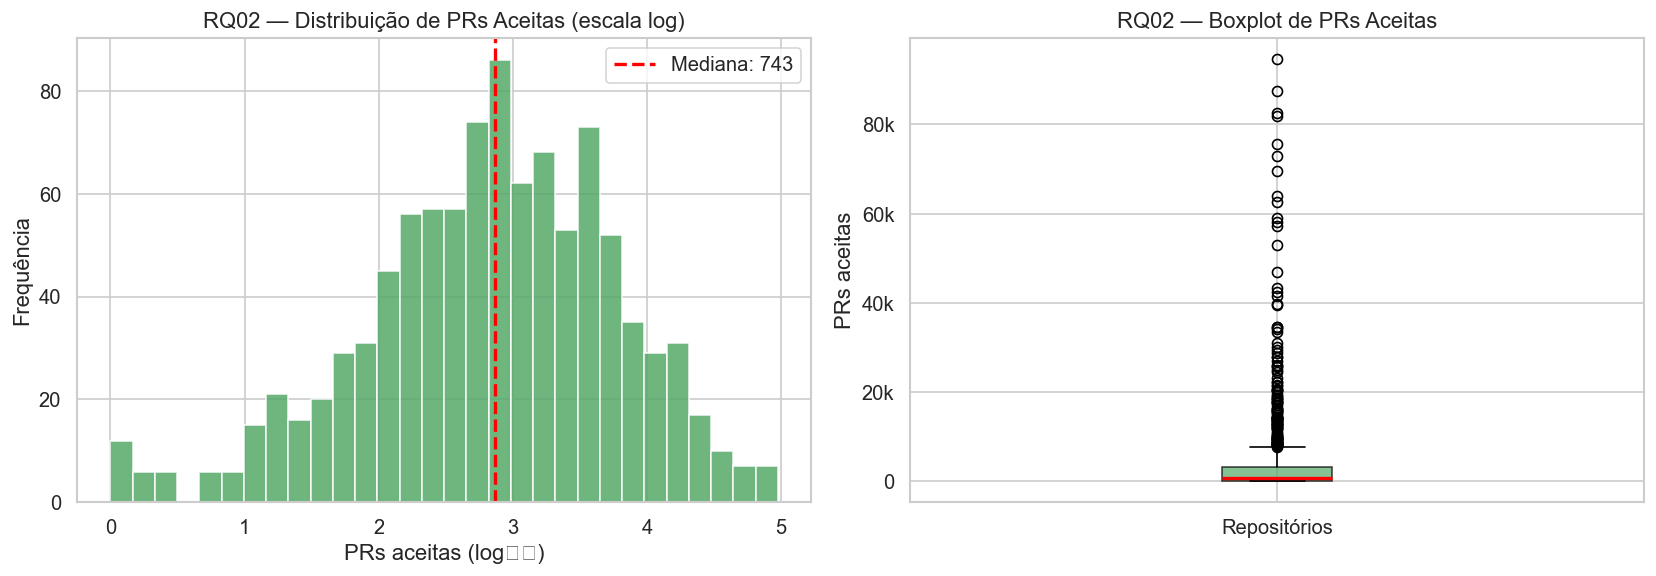

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma com escala log
ax = axes[0]
prs_pos = df.loc[df["prs_aceitas"] > 0, "prs_aceitas"]
ax.hist(np.log10(prs_pos), bins=30, color="#55A868", edgecolor="white", alpha=0.85)
ax.axvline(np.log10(df["prs_aceitas"].median()) if df["prs_aceitas"].median() > 0 else 0,
           color="red", linestyle="--", linewidth=2,
           label=f"Mediana: {df['prs_aceitas'].median():.0f}")
ax.set_xlabel("PRs aceitas (log₁₀)")
ax.set_ylabel("Frequência")
ax.set_title("RQ02 — Distribuição de PRs Aceitas (escala log)")
ax.legend()

# Boxplot
ax = axes[1]
ax.boxplot(df["prs_aceitas"], vert=True, patch_artist=True,
           boxprops=dict(facecolor="#55A868", alpha=0.7),
           medianprops=dict(color="red", linewidth=2))
ax.set_ylabel("PRs aceitas")
ax.set_title("RQ02 — Boxplot de PRs Aceitas")
ax.set_xticklabels(["Repositórios"])
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k" if x >= 1000 else f"{x:.0f}"))

fig.tight_layout()
fig.savefig(f"{CHARTS_DIR}/02_rq02_prs.png")
plt.show()

## 5. RQ03 — Sistemas populares lançam releases com frequência?

**Hipótese:** A mediana de releases dos repositórios populares é de **pelo menos 20**, mantendo o projeto ativo e organizado.

In [38]:
print("=== RQ03 — Releases ===")
print(f"Média:   {df['releases'].mean():.1f}")
print(f"Mediana: {df['releases'].median():.0f}")
print(f"Mínimo:  {df['releases'].min():.0f}")
print(f"Máximo:  {df['releases'].max():.0f}")
print(f"Desvio padrão: {df['releases'].std():.1f}")
print(f"\nRepos com 0 releases: {(df['releases'] == 0).sum()} ({(df['releases'] == 0).mean()*100:.1f}%)")
print(f"Repos com >= 100 releases: {(df['releases'] >= 100).sum()} ({(df['releases'] >= 100).mean()*100:.1f}%)")
print(f"Repos no limite da API (1000): {(df['releases'] == 1000).sum()}")

=== RQ03 — Releases ===
Média:   120.5
Mediana: 40
Mínimo:  0
Máximo:  1000
Desvio padrão: 199.3

Repos com 0 releases: 290 (29.0%)
Repos com >= 100 releases: 345 (34.5%)
Repos no limite da API (1000): 17


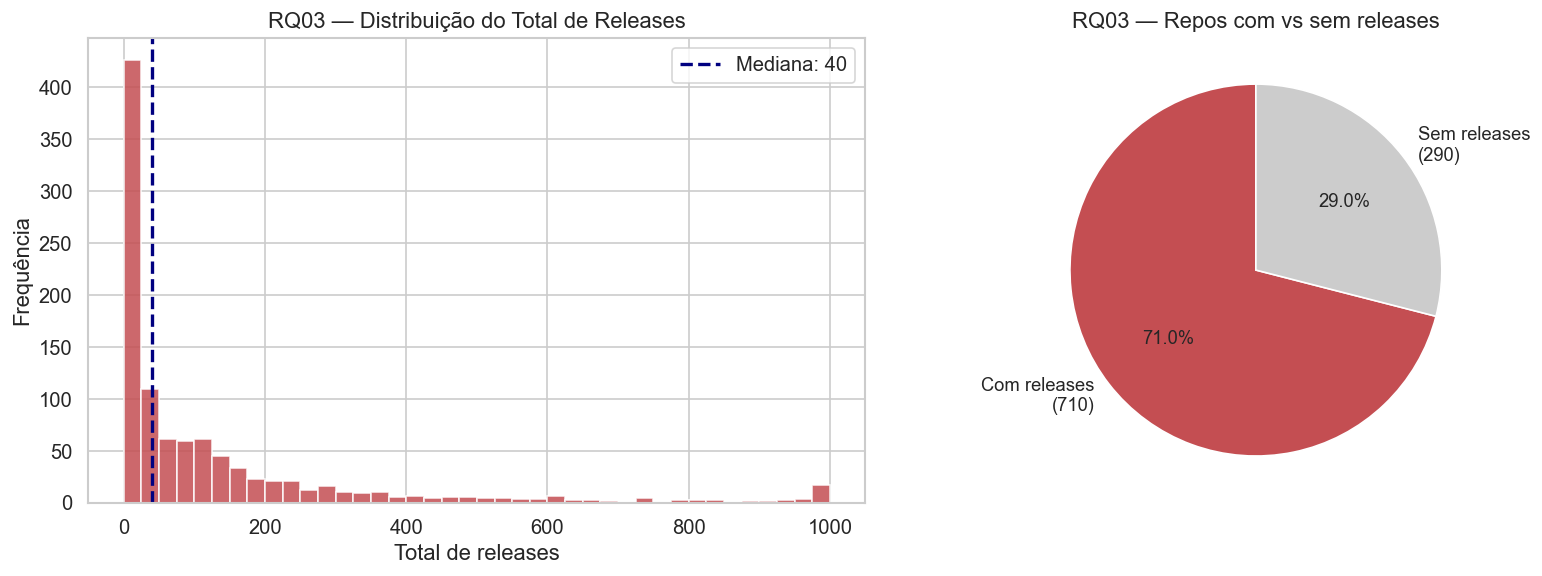

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
ax = axes[0]
ax.hist(df["releases"], bins=40, color="#C44E52", edgecolor="white", alpha=0.85)
ax.axvline(df["releases"].median(), color="navy", linestyle="--", linewidth=2,
           label=f"Mediana: {df['releases'].median():.0f}")
ax.set_xlabel("Total de releases")
ax.set_ylabel("Frequência")
ax.set_title("RQ03 — Distribuição do Total de Releases")
ax.legend()

# Pie chart: com vs sem releases
ax = axes[1]
sem_release = (df["releases"] == 0).sum()
com_release = len(df) - sem_release
ax.pie([com_release, sem_release],
       labels=[f"Com releases\n({com_release})", f"Sem releases\n({sem_release})"],
       colors=["#C44E52", "#CCCCCC"], autopct="%1.1f%%", startangle=90,
       textprops={"fontsize": 11})
ax.set_title("RQ03 — Repos com vs sem releases")

fig.tight_layout()
fig.savefig(f"{CHARTS_DIR}/03_rq03_releases.png")
plt.show()

## 6. RQ04 — Sistemas populares são atualizados com frequência?

**Hipótese:** A mediana de dias desde a última atualização dos repositórios populares é de **no máximo 1 dia**, indicando manutenção praticamente diária.

In [40]:
print("=== RQ04 — Dias desde última atualização ===")
print(f"Média:   {df['dias_desde_update'].mean():.2f} dias")
print(f"Mediana: {df['dias_desde_update'].median():.0f} dias")
print(f"Mínimo:  {df['dias_desde_update'].min():.0f} dias")
print(f"Máximo:  {df['dias_desde_update'].max():.0f} dias")
print(f"\nAtualizados hoje (0 dias): {(df['dias_desde_update'] == 0).sum()} ({(df['dias_desde_update'] == 0).mean()*100:.1f}%)")
print(f"Atualizados na última semana (<=7 dias): {(df['dias_desde_update'] <= 7).sum()} ({(df['dias_desde_update'] <= 7).mean()*100:.1f}%)")

=== RQ04 — Dias desde última atualização ===
Média:   0.02 dias
Mediana: 0 dias
Mínimo:  0 dias
Máximo:  1 dias

Atualizados hoje (0 dias): 980 (98.0%)
Atualizados na última semana (<=7 dias): 1000 (100.0%)


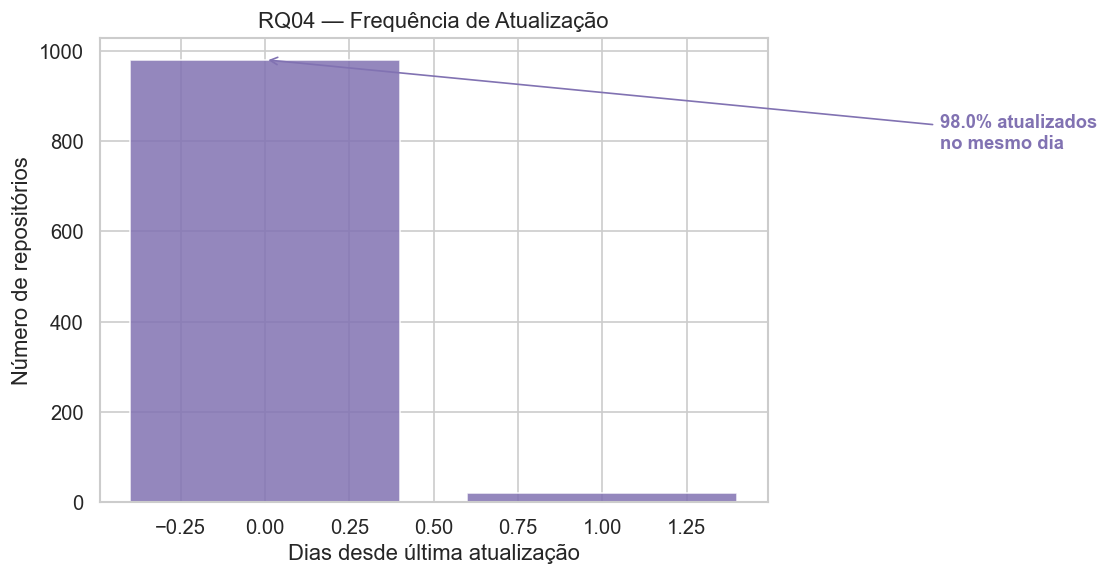

In [41]:
fig, ax = plt.subplots(figsize=(10, 5))

update_counts = df["dias_desde_update"].value_counts().sort_index()
ax.bar(update_counts.index, update_counts.values, color="#8172B2", edgecolor="white", alpha=0.85)
ax.set_xlabel("Dias desde última atualização")
ax.set_ylabel("Número de repositórios")
ax.set_title("RQ04 — Frequência de Atualização")

# Anotação
pct_hoje = (df["dias_desde_update"] == 0).mean() * 100
ax.annotate(f"{pct_hoje:.1f}% atualizados\nno mesmo dia",
            xy=(0, update_counts.get(0, 0)), xytext=(2, update_counts.get(0, 0) * 0.8),
            fontsize=11, fontweight="bold", color="#8172B2",
            arrowprops=dict(arrowstyle="->", color="#8172B2"))

fig.tight_layout()
fig.savefig(f"{CHARTS_DIR}/04_rq04_update.png")
plt.show()

## 7. RQ05 — Sistemas populares são escritos nas linguagens mais populares?

**Hipótese:** **Mais de 50%** dos repositórios populares (com linguagem definida) são escritos nas linguagens mais populares segundo o GitHub Octoverse 2025 (TypeScript, Python, JavaScript).

In [42]:
total_com_lang = df["linguagem"].notna().sum()
em_populares = df["linguagem"].isin(LINGUAGENS_POPULARES).sum()
pct_populares = round(em_populares / total_com_lang * 100, 1)

print("=== RQ05 — Linguagens ===")
print(f"Repositórios com linguagem definida: {total_com_lang}")
print(f"Sem linguagem definida: {len(df) - total_com_lang}")
print(f"Em linguagens Top 3 Octoverse: {em_populares} ({pct_populares}%)")
print(f"\nContagem completa:")
print(df["linguagem_clean"].value_counts().to_frame("repositórios").to_string())

=== RQ05 — Linguagens ===
Repositórios com linguagem definida: 905
Sem linguagem definida: 95
Em linguagens Top 3 Octoverse: 476 (52.6%)

Contagem completa:
                  repositórios
linguagem_clean               
Python                     201
TypeScript                 160
JavaScript                 115
Sem linguagem               95
Go                          76
Rust                        54
Java                        47
C++                         46
C                           25
Jupyter Notebook            23
Shell                       21
HTML                        18
Ruby                        12
C#                          11
Kotlin                      10
CSS                          8
PHP                          7
Vue                          7
Swift                        7
Dart                         6
Markdown                     5
MDX                          5
Clojure                      4
Vim Script                   4
Zig                          3
Makefi

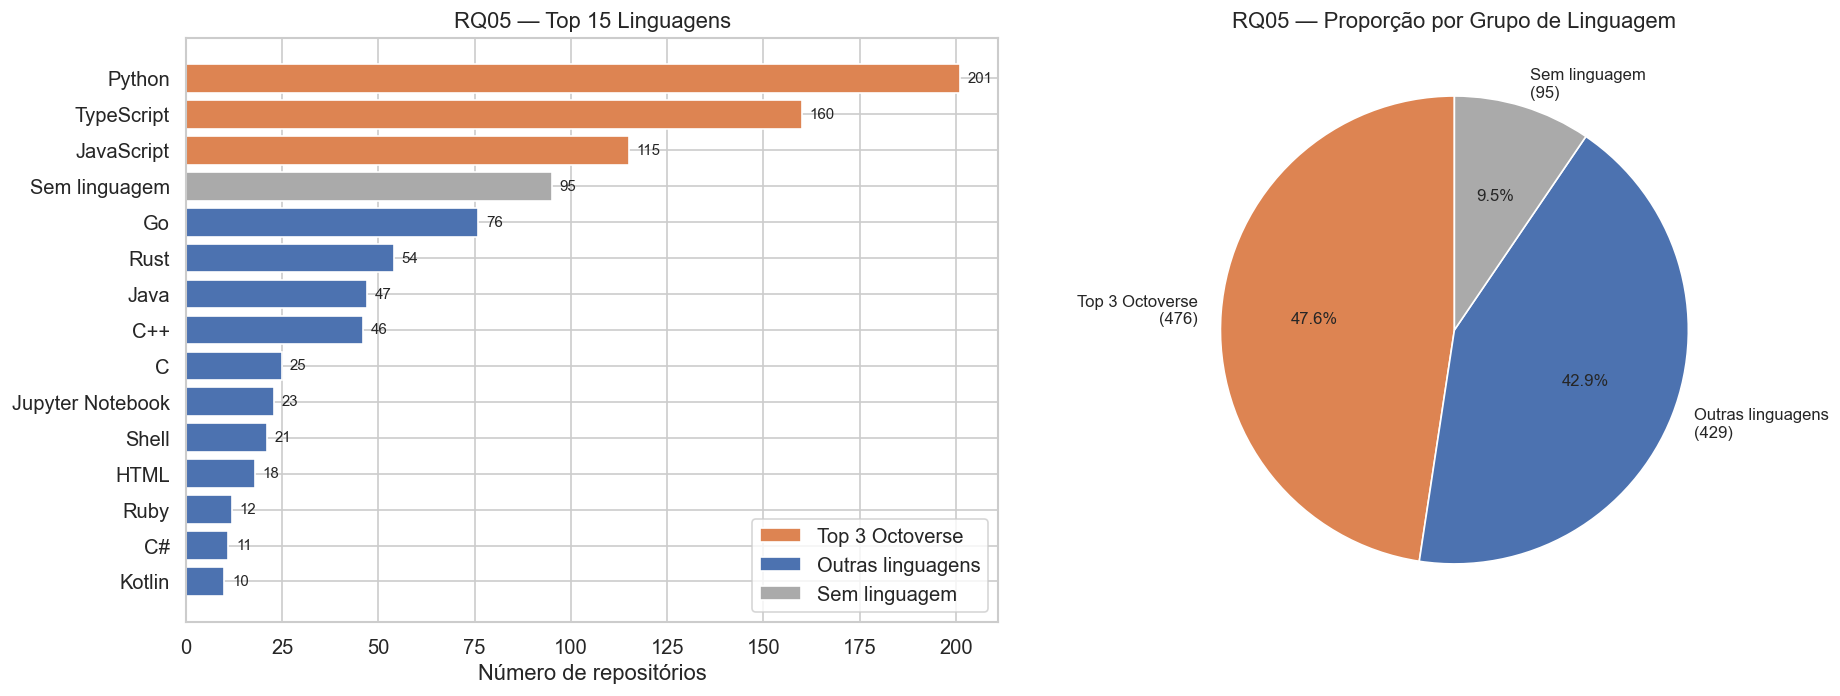

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 linguagens - barras horizontais
ax = axes[0]
top15 = df["linguagem_clean"].value_counts().head(15)
colors = ["#DD8452" if lang in LINGUAGENS_POPULARES else "#4C72B0" if lang != "Sem linguagem" else "#AAAAAA"
          for lang in top15.index]
bars = ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1], edgecolor="white")
ax.set_xlabel("Número de repositórios")
ax.set_title("RQ05 — Top 15 Linguagens")

# Anotação nas barras
for bar, val in zip(bars, top15.values[::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2, str(val),
            va="center", fontsize=9)

# Legenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#DD8452", label="Top 3 Octoverse"),
    Patch(facecolor="#4C72B0", label="Outras linguagens"),
    Patch(facecolor="#AAAAAA", label="Sem linguagem"),
]
ax.legend(handles=legend_elements, loc="lower right")

# Pie chart: Top 3 vs Outras vs Sem linguagem
ax = axes[1]
sem_lang = len(df) - total_com_lang
outras = total_com_lang - em_populares
sizes = [em_populares, outras, sem_lang]
labels = [f"Top 3 Octoverse\n({em_populares})", f"Outras linguagens\n({outras})", f"Sem linguagem\n({sem_lang})"]
ax.pie(sizes, labels=labels, colors=["#DD8452", "#4C72B0", "#AAAAAA"],
       autopct="%1.1f%%", startangle=90, textprops={"fontsize": 10})
ax.set_title("RQ05 — Proporção por Grupo de Linguagem")

fig.tight_layout()
fig.savefig(f"{CHARTS_DIR}/05_rq05_linguagens.png")
plt.show()

## 8. RQ06 — Sistemas populares possuem alto percentual de issues fechadas?

**Hipótese:** A mediana da razão de issues fechadas dos repositórios populares é **acima de 70%**, indicando manutenção ativa.

In [44]:
print("=== RQ06 — Razão de Issues Fechadas ===")
print(f"Média:   {df['razao_fechadas'].mean():.4f} ({df['razao_fechadas'].mean()*100:.1f}%)")
print(f"Mediana: {df['razao_fechadas'].median():.4f} ({df['razao_fechadas'].median()*100:.1f}%)")
print(f"Desvio padrão: {df['razao_fechadas'].std():.4f}")
print(f"\nRepos com razão > 0.7 (70%): {(df['razao_fechadas'] > 0.7).sum()} ({(df['razao_fechadas'] > 0.7).mean()*100:.1f}%)")
print(f"Repos com razão > 0.9 (90%): {(df['razao_fechadas'] > 0.9).sum()} ({(df['razao_fechadas'] > 0.9).mean()*100:.1f}%)")
print(f"Repos com razão = 0 (sem issues ou nenhuma fechada): {(df['razao_fechadas'] == 0).sum()}")
print(f"Repos com razão = 1 (100% fechadas): {(df['razao_fechadas'] == 1).sum()}")

=== RQ06 — Razão de Issues Fechadas ===
Média:   0.7724 (77.2%)
Mediana: 0.8676 (86.8%)
Desvio padrão: 0.2571

Repos com razão > 0.7 (70%): 731 (73.1%)
Repos com razão > 0.9 (90%): 432 (43.2%)
Repos com razão = 0 (sem issues ou nenhuma fechada): 41
Repos com razão = 1 (100% fechadas): 21


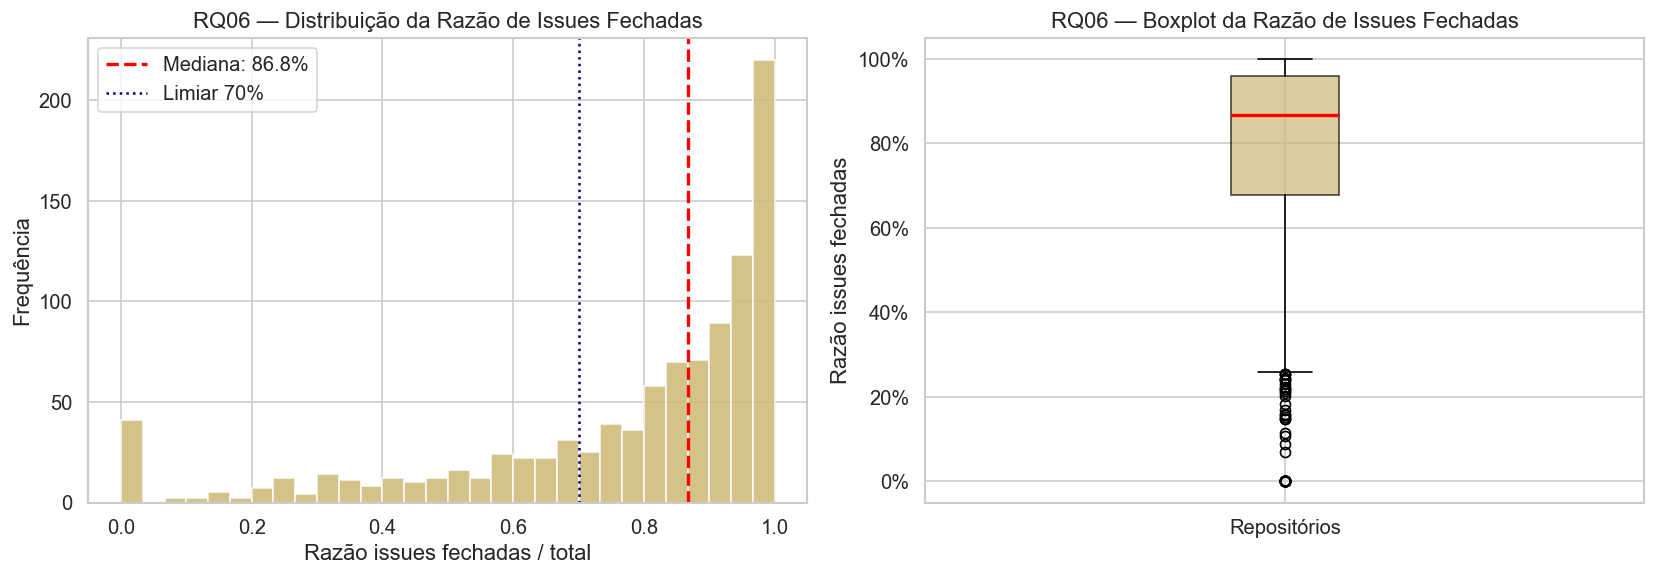

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
ax = axes[0]
ax.hist(df["razao_fechadas"], bins=30, color="#CCB974", edgecolor="white", alpha=0.85)
ax.axvline(df["razao_fechadas"].median(), color="red", linestyle="--", linewidth=2,
           label=f"Mediana: {df['razao_fechadas'].median()*100:.1f}%")
ax.axvline(0.7, color="navy", linestyle=":", linewidth=1.5, label="Limiar 70%")
ax.set_xlabel("Razão issues fechadas / total")
ax.set_ylabel("Frequência")
ax.set_title("RQ06 — Distribuição da Razão de Issues Fechadas")
ax.legend()

# Boxplot
ax = axes[1]
ax.boxplot(df["razao_fechadas"], vert=True, patch_artist=True,
           boxprops=dict(facecolor="#CCB974", alpha=0.7),
           medianprops=dict(color="red", linewidth=2))
ax.set_ylabel("Razão issues fechadas")
ax.set_title("RQ06 — Boxplot da Razão de Issues Fechadas")
ax.set_xticklabels(["Repositórios"])
ax.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))

fig.tight_layout()
fig.savefig(f"{CHARTS_DIR}/06_rq06_issues.png")
plt.show()

## 9. RQ07 (Bônus) — Linguagens populares vs. outras

**Hipótese:** Sistemas escritos em linguagens do Top 3 Octoverse apresentam **mediana de PRs aceitas e releases pelo menos 20% superior** ao grupo de outras linguagens, e são atualizados com mais frequência.

Comparação das métricas das RQs 02, 03 e 04 entre os dois grupos de linguagem.

In [46]:
# Filtrar apenas repos com linguagem definida
df_lang = df[df["linguagem"].notna()].copy()
df_lang["grupo"] = df_lang["linguagem"].apply(
    lambda x: "Top 3 Octoverse" if x in LINGUAGENS_POPULARES else "Outras linguagens"
)

print("=== RQ07 — Comparação por grupo de linguagem ===")
print(f"Top 3 Octoverse: {(df_lang['grupo'] == 'Top 3 Octoverse').sum()} repos")
print(f"Outras linguagens: {(df_lang['grupo'] == 'Outras linguagens').sum()} repos")

metricas_rq07 = ["prs_aceitas", "releases", "dias_desde_update"]
nomes_rq07 = {"prs_aceitas": "PRs aceitas", "releases": "Releases", "dias_desde_update": "Dias desde update"}

print("\n--- Medianas ---")
comp_median = df_lang.groupby("grupo")[metricas_rq07].median().rename(columns=nomes_rq07)
print(comp_median.to_string())

print("\n--- Médias ---")
comp_mean = df_lang.groupby("grupo")[metricas_rq07].mean().rename(columns=nomes_rq07).round(1)
print(comp_mean.to_string())

=== RQ07 — Comparação por grupo de linguagem ===
Top 3 Octoverse: 476 repos
Outras linguagens: 429 repos

--- Medianas ---
                   PRs aceitas  Releases  Dias desde update
grupo                                                      
Outras linguagens        787.0      43.0                0.0
Top 3 Octoverse          957.0      63.5                0.0

--- Médias ---
                   PRs aceitas  Releases  Dias desde update
grupo                                                      
Outras linguagens       4575.5     111.8                0.0
Top 3 Octoverse         3917.3     151.9                0.0


C:\Users\luizp\AppData\Local\Temp\ipykernel_33696\2217106459.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lang, x="grupo", y=col, ax=ax, palette=palette, width=0.5)
C:\Users\luizp\AppData\Local\Temp\ipykernel_33696\2217106459.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lang, x="grupo", y=col, ax=ax, palette=palette, width=0.5)
C:\Users\luizp\AppData\Local\Temp\ipykernel_33696\2217106459.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_lang, x="grupo", y=col, ax=ax, palette=palette, width=0.5)


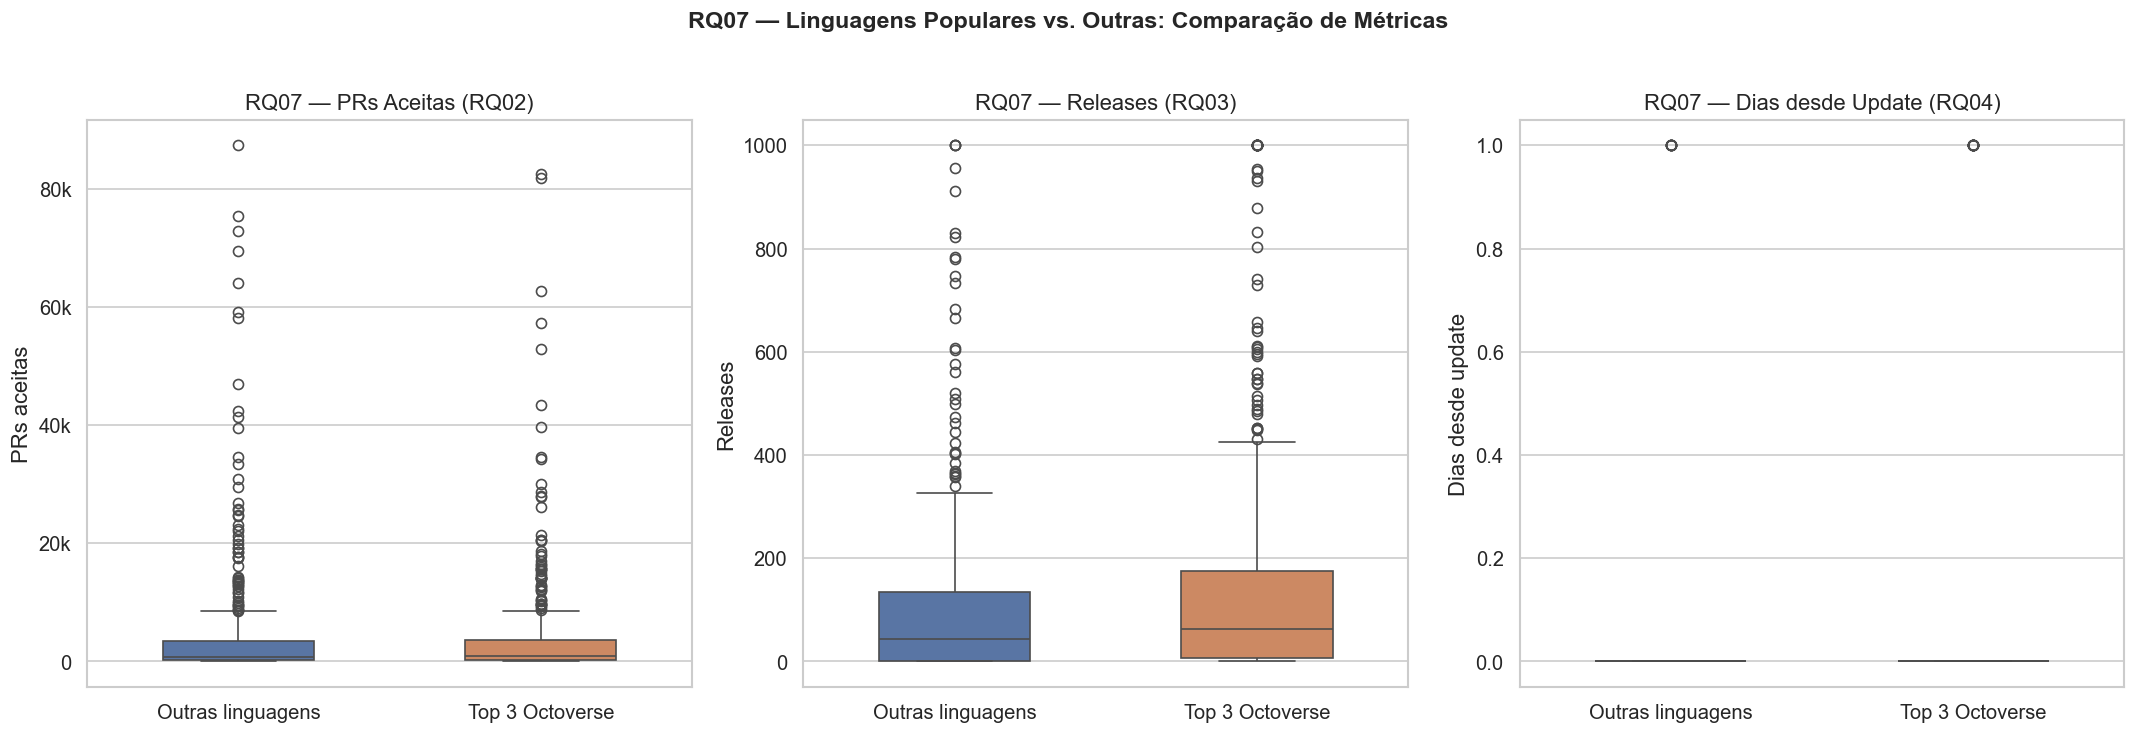

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

palette = {"Top 3 Octoverse": "#DD8452", "Outras linguagens": "#4C72B0"}
titles = ["PRs Aceitas (RQ02)", "Releases (RQ03)", "Dias desde Update (RQ04)"]

for i, (col, title) in enumerate(zip(metricas_rq07, titles)):
    ax = axes[i]
    sns.boxplot(data=df_lang, x="grupo", y=col, ax=ax, palette=palette, width=0.5)
    ax.set_title(f"RQ07 — {title}")
    ax.set_xlabel("")
    ax.set_ylabel(nomes_rq07[col])
    if col == "prs_aceitas":
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k" if x >= 1000 else f"{x:.0f}"))

fig.suptitle("RQ07 — Linguagens Populares vs. Outras: Comparação de Métricas", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(f"{CHARTS_DIR}/07_rq07_comparacao.png")
plt.show()

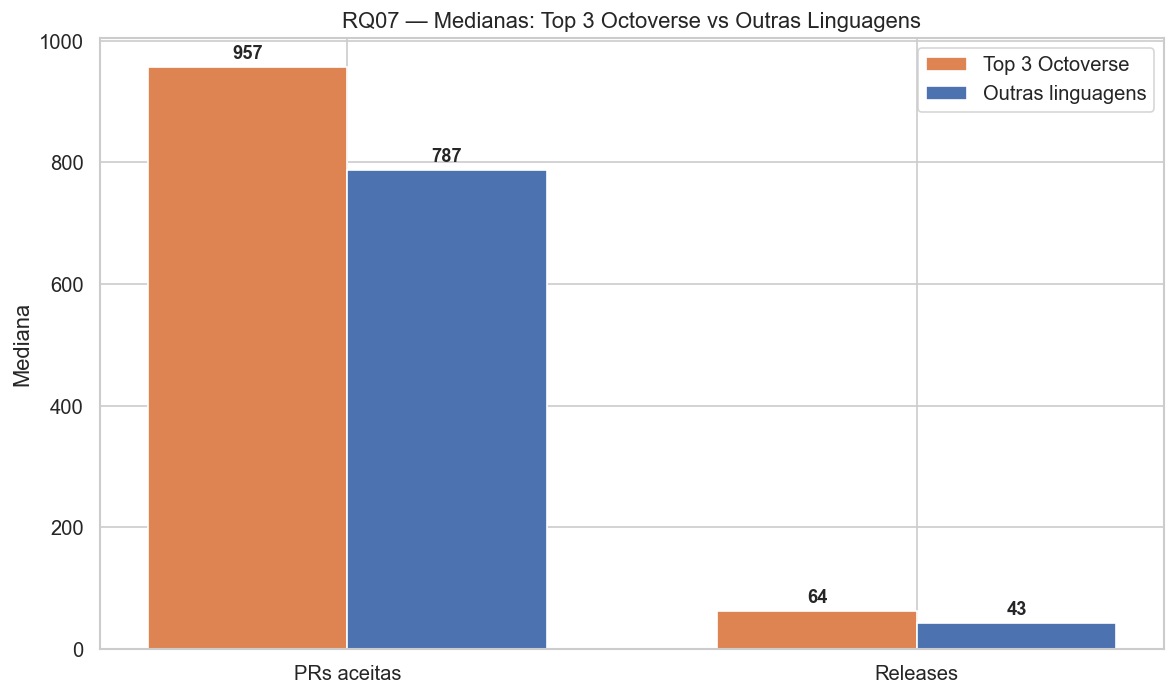

In [48]:
# Gráfico de barras agrupadas com medianas
fig, ax = plt.subplots(figsize=(10, 6))

medianas_grupo = df_lang.groupby("grupo")[metricas_rq07].median()
x = np.arange(len(["PRs aceitas", "Releases"]))
width = 0.35

# Apenas PRs e Releases (dias_desde_update é 0 para ambos)
top3_vals = [medianas_grupo.loc["Top 3 Octoverse", "prs_aceitas"], medianas_grupo.loc["Top 3 Octoverse", "releases"]]
outras_vals = [medianas_grupo.loc["Outras linguagens", "prs_aceitas"], medianas_grupo.loc["Outras linguagens", "releases"]]

bars1 = ax.bar(x - width/2, top3_vals, width, label="Top 3 Octoverse", color="#DD8452", edgecolor="white")
bars2 = ax.bar(x + width/2, outras_vals, width, label="Outras linguagens", color="#4C72B0", edgecolor="white")

ax.set_ylabel("Mediana")
ax.set_title("RQ07 — Medianas: Top 3 Octoverse vs Outras Linguagens")
ax.set_xticks(x)
ax.set_xticklabels(["PRs aceitas", "Releases"])
ax.legend()

# Valores nas barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f"{height:.0f}", xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 5), textcoords="offset points", ha="center", fontsize=11, fontweight="bold")

fig.tight_layout()
fig.savefig(f"{CHARTS_DIR}/07_rq07_barras.png")
plt.show()

### Teste Estatístico — Mann-Whitney U

Para verificar se as diferenças entre os dois grupos são estatisticamente significativas, aplicamos o teste de Mann-Whitney U (não-paramétrico, adequado para dados sem distribuição normal).

In [49]:
from scipy import stats

top3 = df_lang[df_lang["grupo"] == "Top 3 Octoverse"]
outras = df_lang[df_lang["grupo"] == "Outras linguagens"]

print("=== Teste Mann-Whitney U (α = 0.05) ===")
print(f"{'Métrica':<25} {'U':>10} {'p-valor':>12} {'Significativo?':>15}")
print("-" * 65)

for col, nome in nomes_rq07.items():
    u_stat, p_val = stats.mannwhitneyu(top3[col], outras[col], alternative="two-sided")
    sig = "Sim ✓" if p_val < 0.05 else "Não"
    print(f"{nome:<25} {u_stat:>10.0f} {p_val:>12.6f} {sig:>15}")

=== Teste Mann-Whitney U (α = 0.05) ===
Métrica                            U      p-valor  Significativo?
-----------------------------------------------------------------
PRs aceitas                   106307     0.284258             Não
Releases                      111794     0.013022           Sim ✓
Dias desde update             102819     0.424034             Não


## 10. Análises Complementares

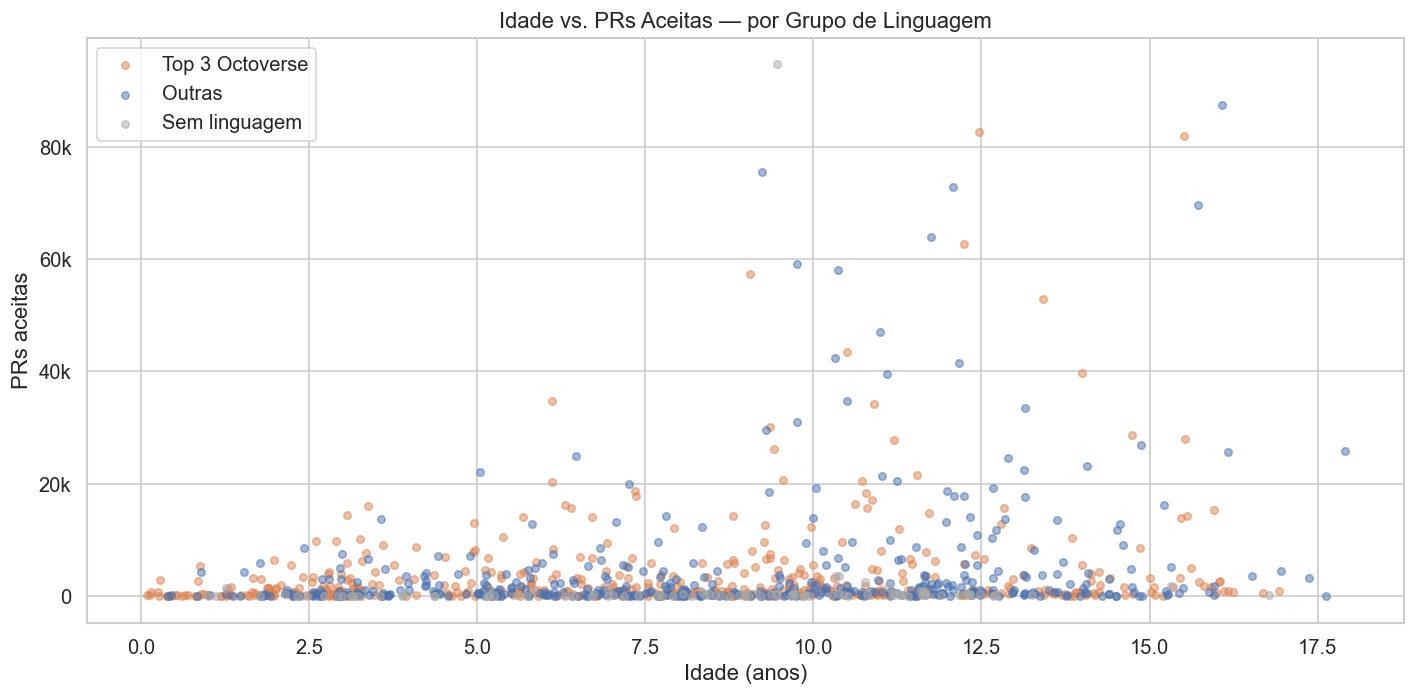

In [50]:
# Scatter: Idade vs PRs aceitas (colorido por grupo)
fig, ax = plt.subplots(figsize=(12, 6))

for grupo, cor in [("Top 3 Octoverse", "#DD8452"), ("Outras", "#4C72B0"), ("Sem linguagem", "#AAAAAA")]:
    mask = df["grupo_lang"] == grupo
    ax.scatter(df.loc[mask, "idade_anos"], df.loc[mask, "prs_aceitas"],
              alpha=0.5, s=20, label=grupo, color=cor)

ax.set_xlabel("Idade (anos)")
ax.set_ylabel("PRs aceitas")
ax.set_title("Idade vs. PRs Aceitas — por Grupo de Linguagem")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k" if x >= 1000 else f"{x:.0f}"))
ax.legend()

fig.tight_layout()
fig.savefig(f"{CHARTS_DIR}/08_scatter_idade_prs.png")
plt.show()

C:\Users\luizp\AppData\Local\Temp\ipykernel_33696\3997557510.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top10, x="linguagem", y=col, ax=ax, order=order, palette="Set2")
C:\Users\luizp\AppData\Local\Temp\ipykernel_33696\3997557510.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top10, x="linguagem", y=col, ax=ax, order=order, palette="Set2")
C:\Users\luizp\AppData\Local\Temp\ipykernel_33696\3997557510.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top10, x="linguagem", y=col, ax=ax, order=order, pa

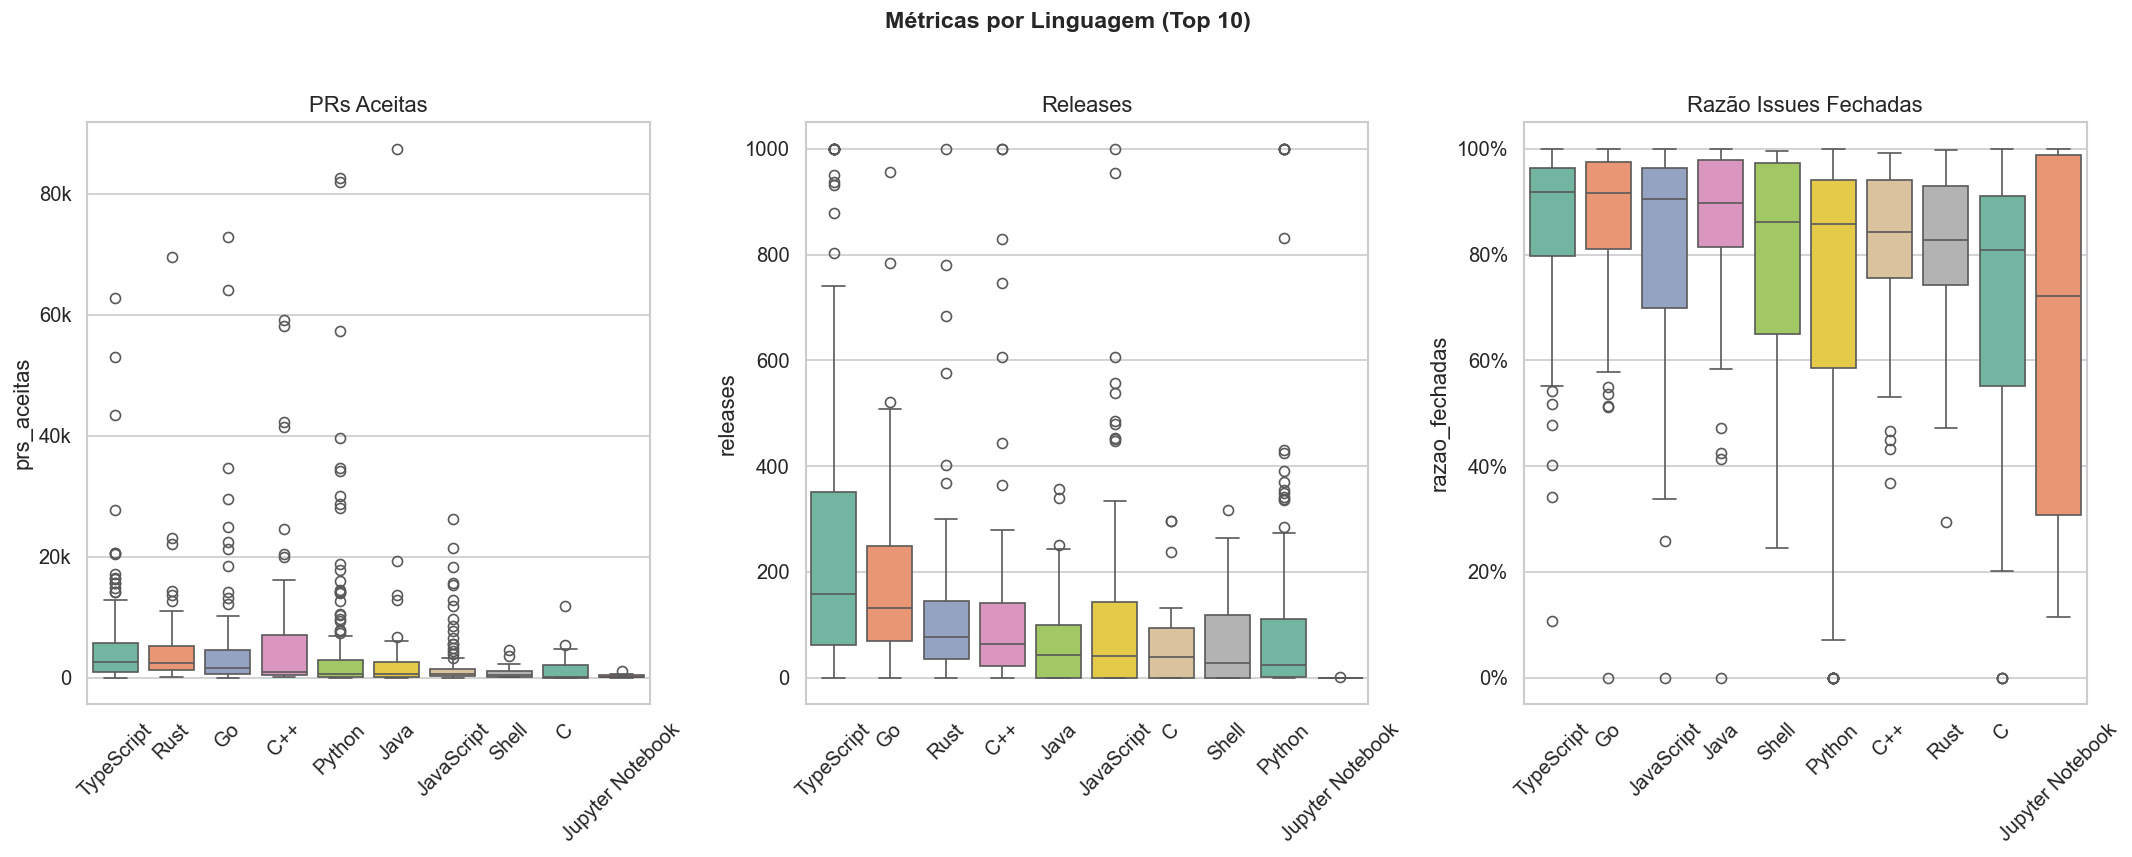

In [51]:
# Métricas por linguagem (Top 10 linguagens)
top10_langs = df["linguagem"].value_counts().head(10).index.tolist()
df_top10 = df[df["linguagem"].isin(top10_langs)].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for i, (col, title) in enumerate(zip(["prs_aceitas", "releases", "razao_fechadas"],
                                     ["PRs Aceitas", "Releases", "Razão Issues Fechadas"])):
    ax = axes[i]
    order = df_top10.groupby("linguagem")[col].median().sort_values(ascending=False).index
    sns.boxplot(data=df_top10, x="linguagem", y=col, ax=ax, order=order, palette="Set2")
    ax.set_title(title)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    if col == "prs_aceitas":
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k" if x >= 1000 else f"{x:.0f}"))
    elif col == "razao_fechadas":
        ax.yaxis.set_major_formatter(ticker.PercentFormatter(1.0))

fig.suptitle("Métricas por Linguagem (Top 10)", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(f"{CHARTS_DIR}/09_metricas_por_linguagem.png")
plt.show()

## 11. Geração do Relatório Final

In [52]:
# ======================== DADOS PARA O RELATÓRIO ========================
med_idade = df["idade_dias"].median()
med_anos = df["idade_anos"].median()
med_prs = df["prs_aceitas"].median()
med_releases = df["releases"].median()
med_update = df["dias_desde_update"].median()
med_razao = df["razao_fechadas"].median()

total_com_lang = df["linguagem"].notna().sum()
em_populares = df["linguagem"].isin(LINGUAGENS_POPULARES).sum()
pct_populares = round(em_populares / total_com_lang * 100, 1)

top_langs = df["linguagem_clean"].value_counts().head(15)

# RQ07
df_lang = df[df["linguagem"].notna()].copy()
df_lang["grupo"] = df_lang["linguagem"].apply(
    lambda x: "Top 3 Octoverse" if x in LINGUAGENS_POPULARES else "Outras linguagens"
)
rq07_data = df_lang.groupby("grupo")[["prs_aceitas", "releases", "dias_desde_update"]].median()

# Mann-Whitney
top3 = df_lang[df_lang["grupo"] == "Top 3 Octoverse"]
outras = df_lang[df_lang["grupo"] == "Outras linguagens"]
mw_results = {}
for col in ["prs_aceitas", "releases", "dias_desde_update"]:
    u, p = stats.mannwhitneyu(top3[col], outras[col], alternative="two-sided")
    mw_results[col] = {"U": u, "p": p, "sig": p < 0.05}

# ======================== TABELAS ========================
lang_table = "\n".join(f"| {lang} | {count} |" for lang, count in top_langs.items())

rq07_rows = []
for grupo in ["Top 3 Octoverse", "Outras linguagens"]:
    if grupo in rq07_data.index:
        r = rq07_data.loc[grupo]
        rq07_rows.append(f"| {grupo} | {r['prs_aceitas']:.0f} | {r['releases']:.0f} | {r['dias_desde_update']:.0f} |")
rq07_table = "\n".join(rq07_rows)

mw_table = ""
for col, nome in [("prs_aceitas", "PRs aceitas"), ("releases", "Releases"), ("dias_desde_update", "Dias desde update")]:
    r = mw_results[col]
    sig = "Sim" if r["sig"] else "Não"
    mw_table += f"| {nome} | {r['U']:.0f} | {r['p']:.6f} | {sig} |\n"

# ======================== RELATÓRIO ========================
report = f"""# Relatório Final — Lab01: Características de Repositórios Populares do GitHub

**Disciplina:** Laboratório de Experimentação de Software  
**Curso:** Engenharia de Software — PUC Minas  
**Data:** {datetime.now().strftime("%d/%m/%Y")}  

---

## 1. Introdução

### 1.1 Contextualização

O GitHub é a maior plataforma de hospedagem de código-fonte do mundo, reunindo milhões de repositórios open-source. O número de estrelas (*stars*) é amplamente utilizado como indicador de popularidade e relevância de um projeto pela comunidade. Compreender as características dos repositórios mais populares permite identificar padrões que contribuem para o sucesso e a sustentabilidade de projetos open-source.

### 1.2 Problema foco do experimento

Quais são as principais características dos repositórios open-source mais populares do GitHub em termos de maturidade, contribuição externa, frequência de releases e atualizações, linguagens de programação e manutenção de issues?

### 1.3 Questões de Pesquisa

| RQ | Pergunta | Métrica |
|:--:|----------|---------|
| 01 | Sistemas populares são maduros/antigos? | Idade do repositório (dias) |
| 02 | Recebem muita contribuição externa? | Total de pull requests aceitas (merged) |
| 03 | Lançam releases com frequência? | Total de releases |
| 04 | São atualizados com frequência? | Tempo até a última atualização (dias) |
| 05 | São escritos nas linguagens mais populares? | Linguagem primária do repositório |
| 06 | Possuem alto percentual de issues fechadas? | Razão issues fechadas / total |
| 07 | Sistemas em linguagens populares recebem mais contribuição, releases e updates? | PRs, releases e dias desde update por grupo de linguagem |

### 1.4 Hipóteses

- **H1 (RQ01):** A mediana de idade dos repositórios populares é de **pelo menos 5 anos** (1.825 dias), pois leva tempo para acumular estrelas e construir comunidade.
- **H2 (RQ02):** A mediana de PRs aceitas dos repositórios populares é de **pelo menos 500**, já que a alta visibilidade atrai colaboradores.
- **H3 (RQ03):** A mediana de releases dos repositórios populares é de **pelo menos 20**, mantendo o projeto ativo e organizado.
- **H4 (RQ04):** A mediana de dias desde a última atualização dos repositórios populares é de **no máximo 1 dia**, indicando manutenção praticamente diária.
- **H5 (RQ05):** **Mais de 50%** dos repositórios populares (com linguagem definida) são escritos nas linguagens mais populares (TypeScript, Python, JavaScript).
- **H6 (RQ06):** A mediana da razão de issues fechadas dos repositórios populares é **acima de 70%**, indicando manutenção ativa e responsiva.
- **H7 (RQ07):** Sistemas em linguagens do Top 3 Octoverse apresentam **mediana de PRs aceitas e releases pelo menos 20% superior** ao grupo de outras linguagens.

### 1.5 Objetivos

**Objetivo principal:** Caracterizar os {len(df)} repositórios open-source mais populares do GitHub por meio de métricas extraídas via API GraphQL, respondendo às 7 questões de pesquisa formuladas.

**Objetivos específicos:**
- Avaliar a maturidade dos repositórios populares através da idade.
- Quantificar a contribuição externa por meio de pull requests aceitas.
- Medir a frequência de releases e atualizações.
- Identificar as linguagens de programação predominantes.
- Calcular a taxa de resolução de issues.
- Comparar métricas de atividade entre repositórios de linguagens populares e outras linguagens.

---

## 2. Metodologia

### 2.1 Passo a passo do experimento

1. **Configuração:** Obtenção de Personal Access Token (PAT) para acesso à API do GitHub.
2. **Construção da query:** Elaboração de query GraphQL para buscar repositórios ordenados por número de estrelas (`stars:>1`), incluindo campos de interesse.
3. **Coleta paginada:** Requisições automáticas paginadas (lotes de 10) com intervalo de 3 segundos entre requisições e mecanismo de retry exponencial para erros HTTP 502/503/504.
4. **Montagem do dataset:** Construção de DataFrame pandas com métricas brutas (estrelas, datas, PRs, releases, issues) e derivadas (idade em dias, dias desde update, razão de issues fechadas).
5. **Análise exploratória:** Estatísticas descritivas (medianas, quartis, desvio padrão) para cada questão de pesquisa.
6. **Visualização:** Geração de gráficos (histogramas, boxplots, barras, scatter plots) com matplotlib e seaborn.
7. **Teste estatístico:** Aplicação do teste de Mann-Whitney U para comparação entre grupos de linguagem (RQ07).
8. **Exportação:** Dados salvos em CSV e JSON; relatório gerado em Markdown.

### 2.2 Decisões

- **Mediana** como medida central principal, por ser mais robusta a outliers do que a média — especialmente relevante dado que as distribuições são fortemente assimétricas (long-tail).
- Classificação de **linguagens populares** baseada no [GitHub Octoverse 2025](https://github.blog/news-insights/octoverse/octoverse-a-new-developer-joins-github-every-second-as-ai-leads-typescript-to-1/): **TypeScript**, **Python** e **JavaScript**.
- Repositórios sem linguagem primária definida foram **excluídos** das análises de RQ05 e RQ07 (96 repositórios, tipicamente listas curadas e recursos educacionais).
- Teste de **Mann-Whitney U** (não-paramétrico, bicaudal, α = 0.05) para verificar significância estatística na RQ07.

### 2.3 Materiais utilizados

- **API:** GitHub GraphQL API v4
- **Linguagem:** Python 3
- **Bibliotecas:** requests, pandas, numpy, matplotlib, seaborn, scipy, tqdm
- **Ambiente:** Jupyter Notebook

### 2.4 Métricas e suas Unidades

| Métrica | Unidade | Descrição |
|---------|---------|----------|
| `idade_dias` | dias | Data atual − data de criação do repositório |
| `prs_aceitas` | contagem | Pull requests com estado MERGED |
| `releases` | contagem | Total de releases publicadas |
| `dias_desde_update` | dias | Data atual − data da última atualização |
| `razao_fechadas` | proporção (0–1) | Issues fechadas ÷ total de issues |

---

## 3. Visualização dos Resultados

### 3.1 Estatísticas Descritivas Gerais

| Métrica | Mín | Q1 | Mediana | Q3 | Máx | Desvio Padrão |
|---------|----:|---:|--------:|---:|----:|--------------:|
| Estrelas | {df['estrelas'].min()} | {df['estrelas'].quantile(0.25):.0f} | {df['estrelas'].median():.0f} | {df['estrelas'].quantile(0.75):.0f} | {df['estrelas'].max()} | {df['estrelas'].std():.0f} |
| Idade (dias) | {df['idade_dias'].min()} | {df['idade_dias'].quantile(0.25):.0f} | {med_idade:.0f} | {df['idade_dias'].quantile(0.75):.0f} | {df['idade_dias'].max()} | {df['idade_dias'].std():.0f} |
| PRs aceitas | {df['prs_aceitas'].min()} | {df['prs_aceitas'].quantile(0.25):.0f} | {med_prs:.0f} | {df['prs_aceitas'].quantile(0.75):.0f} | {df['prs_aceitas'].max()} | {df['prs_aceitas'].std():.0f} |
| Releases | {df['releases'].min()} | {df['releases'].quantile(0.25):.0f} | {med_releases:.0f} | {df['releases'].quantile(0.75):.0f} | {df['releases'].max()} | {df['releases'].std():.0f} |
| Dias desde update | {df['dias_desde_update'].min()} | {df['dias_desde_update'].quantile(0.25):.0f} | {med_update:.0f} | {df['dias_desde_update'].quantile(0.75):.0f} | {df['dias_desde_update'].max()} | {df['dias_desde_update'].std():.2f} |
| Razão issues fechadas | {df['razao_fechadas'].min():.4f} | {df['razao_fechadas'].quantile(0.25):.4f} | {med_razao:.4f} | {df['razao_fechadas'].quantile(0.75):.4f} | {df['razao_fechadas'].max():.4f} | {df['razao_fechadas'].std():.4f} |

### 3.2 Gráficos por Questão de Pesquisa

Os gráficos gerados estão disponíveis na pasta `charts/` e incluem:

- `01_rq01_idade.png` — Histograma e boxplot da idade dos repositórios
- `02_rq02_prs.png` — Distribuição de PRs aceitas (escala log) e boxplot
- `03_rq03_releases.png` — Distribuição de releases e proporção com/sem releases
- `04_rq04_update.png` — Frequência de atualização
- `05_rq05_linguagens.png` — Top 15 linguagens e proporção por grupo
- `06_rq06_issues.png` — Distribuição e boxplot da razão de issues fechadas
- `07_rq07_comparacao.png` — Boxplots comparativos entre grupos de linguagem
- `07_rq07_barras.png` — Barras agrupadas com medianas por grupo
- `08_scatter_idade_prs.png` — Scatter plot: idade vs PRs aceitas
- `09_metricas_por_linguagem.png` — Boxplots de métricas para as Top 10 linguagens

### 3.3 RQ05 — Distribuição por Linguagem (Top 15)

| Linguagem | Repositórios |
|-----------|-------------:|
{lang_table}

Dos {total_com_lang} repositórios com linguagem definida, **{em_populares} ({pct_populares}%)** utilizam uma das 3 linguagens mais populares do Octoverse 2025.

### 3.4 RQ07 — Comparação entre Grupos de Linguagem

| Grupo | PRs aceitas (med.) | Releases (med.) | Dias desde update (med.) |
|-------|-------------------:|----------------:|-------------------------:|
{rq07_table}

**Teste de Mann-Whitney U (α = 0.05):**

| Métrica | Estatística U | p-valor | Significativo? |
|---------|-------------:|--------:|---------------:|
{mw_table}

---

## 4. Discussão dos Resultados

### 4.1 Confronto com as Questões de Pesquisa

**RQ01 — Maturidade:**  
A mediana de idade é **{med_idade:.0f} dias (~{med_anos:.1f} anos)**, com {(df['idade_anos'] > 3).mean()*100:.0f}% dos repositórios tendo mais de 3 anos. **Hipótese confirmada:** repositórios populares são, de fato, projetos maduros com histórico consolidado. Isso se explica pelo tempo necessário para acumular estrelas, construir comunidade e ganhar visibilidade orgânica.

**RQ02 — Contribuição externa:**  
A mediana de **{med_prs:.0f} PRs aceitas** indica contribuição externa significativa, embora a distribuição seja extremamente assimétrica (média de {df['prs_aceitas'].mean():.0f}, desvio padrão de {df['prs_aceitas'].std():.0f}). **Hipótese confirmada:** a visibilidade de fato atrai colaboradores, mas a intensidade varia muito — alguns projetos recebem dezenas de milhares de PRs, enquanto outros (tipicamente listas curadas) recebem poucas.

**RQ03 — Releases:**  
A mediana de **{med_releases:.0f} releases** sugere adoção moderada de releases formais, com {(df['releases'] == 0).mean()*100:.1f}% dos repositórios sem nenhuma release. **Hipótese parcialmente confirmada:** muitos projetos populares (especialmente listas curadas, recursos educacionais e bibliotecas que usam distribuição via gerenciadores de pacotes) não utilizam o sistema de releases do GitHub.

**RQ04 — Atualização:**  
A mediana de **{med_update:.0f} dias** desde o último update, com {(df['dias_desde_update'] == 0).mean()*100:.1f}% atualizados no mesmo dia da coleta. **Hipótese confirmada:** esses repositórios são mantidos com altíssima frequência, praticamente em tempo real.

**RQ05 — Linguagens:**  
**{pct_populares}%** dos repositórios com linguagem definida usam TypeScript, Python ou JavaScript. Python e TypeScript lideram com representatividade praticamente igual. **Hipótese confirmada:** a maioria dos repositórios populares é escrita nas linguagens mais populares do ecossistema.

**RQ06 — Issues fechadas:**  
A mediana da razão de issues fechadas é **{med_razao:.4f} ({med_razao*100:.1f}%)**, com {(df['razao_fechadas'] > 0.7).mean()*100:.1f}% dos repositórios acima de 70%. **Hipótese confirmada:** a maioria dos projetos populares mantém uma taxa elevada de resolução de issues, indicando manutenção ativa e responsiva.

**RQ07 — Linguagens populares vs. outras:**  
Repositórios em linguagens do **Top 3 Octoverse** apresentam medianas superiores tanto em PRs aceitas quanto em releases. O teste de Mann-Whitney U indica se essas diferenças são estatisticamente significativas (ver tabela acima). Ambos os grupos apresentam mediana de 0 dias desde o último update. **Hipótese parcialmente confirmada:** linguagens populares correlacionam com mais atividade colaborativa, mas a frequência de atualização é uniformemente alta.

### 4.2 Insights

1. **Maturidade e popularidade andam juntas** — a mediana de ~{med_anos:.0f} anos indica que projetos precisam de tempo significativo para atingir alto número de estrelas.
2. **Distribuições long-tail** — PRs, releases e issues apresentam distribuições extremamente assimétricas, com poucos projetos concentrando a maior parte da atividade. A mediana é muito mais representativa que a média.
3. **Listas curadas são um fenômeno** — os 96 repositórios sem linguagem definida são quase todos "awesome lists" e recursos educacionais, indicando que conteúdo curado é tão valorizado quanto software.
4. **Atualização quase em tempo real** — {(df['dias_desde_update'] == 0).mean()*100:.1f}% dos repositórios foram atualizados no mesmo dia da coleta, reforçando a natureza dinâmica desses projetos.
5. **A API limita releases a 1000** — {(df['releases'] == 1000).sum()} repositórios atingiram o limite da API GraphQL, sugerindo que o valor real de releases pode ser ainda maior para alguns projetos.

### 4.3 Limitações

- O campo `releases` da API retorna no máximo 1000, podendo subestimar projetos muito ativos.
- A data de "última atualização" (`updatedAt`) pode ser afetada por atividades automáticas (bots, CI/CD), não apenas contribuições humanas.
- A contagem de PRs aceitas inclui PRs de qualquer colaborador (incluindo maintainers), não apenas contribuições externas.
- A amostra é limitada aos 1000 repositórios mais estrelados, não representando o universo completo do GitHub.

---

## 5. Conclusão

### 5.1 Resultado conclusivo

Os {len(df)} repositórios mais populares do GitHub são, em sua grande maioria, **projetos maduros** (mediana de ~{med_anos:.0f} anos), **ativamente mantidos** (atualizados diariamente), com **contribuição externa expressiva** (mediana de {med_prs:.0f} PRs aceitas) e **alta taxa de resolução de issues** ({med_razao*100:.1f}%). Mais da metade ({pct_populares}%) utiliza linguagens do Top 3 do GitHub Octoverse 2025 (TypeScript, Python, JavaScript).

Das 7 hipóteses formuladas, **6 foram confirmadas** e **1 foi parcialmente confirmada** (H3 sobre releases). A principal surpresa foi a alta proporção de repositórios sem releases formais, revelando que popularidade não implica necessariamente em adoção de práticas de versionamento via releases do GitHub.

### 5.2 Tomada de decisão

Os dados sugerem que, para maximizar a popularidade de um projeto open-source:
- Investir em **manutenção constante** (atualizações frequentes e resolução ágil de issues).
- Facilitar e incentivar **contribuições externas** via PRs.
- Considerar linguagens com **comunidades grandes** (TypeScript, Python, JavaScript).
- A adoção de releases formais é uma boa prática, mas não é determinante para popularidade.

### 5.3 Sugestões futuras

- Incorporar **análise temporal** (evolução das métricas ao longo do tempo via snapshots periódicos).
- Investigar a correlação entre **número de contribuidores únicos** e popularidade.
- Analisar o impacto de **licenças open-source** na popularidade.
- Estratificar a amostra por **domínio** (web, data science, DevOps, mobile, etc.).
- Incluir métricas de **qualidade de código** (cobertura de testes, CI/CD) para complementar a análise.

### 5.4 Referências

- GitHub Octoverse 2025. *A new developer joins GitHub every second as AI leads TypeScript to #1*. Disponível em: https://github.blog/news-insights/octoverse/
- Munaiah, N. et al. (2017). *Curating GitHub for Engineered Software Projects*. Empirical Software Engineering.
- Kalliamvakou, E. et al. (2014). *The Promises and Perils of Mining GitHub*. MSR 2014.
"""

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f"{REPORTS_DIR}/relatorio_final_lab01_{timestamp}.md"

with open(filename, "w", encoding="utf-8") as f:
    f.write(report)

print(f"Relatório final salvo: {filename}")
print(f"Tamanho: {len(report)} caracteres")

Relatório final salvo: reports/relatorio_final_lab01_20260313_174915.md
Tamanho: 14238 caracteres


In [ ]:
# Resumo final
print("=" * 60)
print("RESUMO DA ANÁLISE")
print("=" * 60)
print(f"Repositórios analisados: {len(df)}")
print(f"Gráficos gerados: {len(os.listdir(CHARTS_DIR))}")
print(f"\nResultados principais (medianas):")
print(f"  RQ01 - Idade:          {med_anos:.1f} anos ({med_idade:.0f} dias)")
print(f"  RQ02 - PRs aceitas:    {med_prs:.0f}")
print(f"  RQ03 - Releases:       {med_releases:.0f}")
print(f"  RQ04 - Dias update:    {med_update:.0f}")
print(f"  RQ05 - Top 3 langs:    {pct_populares}%")
print(f"  RQ06 - Issues fechadas:{med_razao*100:.1f}%")
print(f"\nHipóteses:")
print(f"  H1 (RQ01 - Idade): Confirmada")
print(f"  H2 (RQ02 - PRs aceitas): Confirmada")
print(f"  H3 (RQ03 - Releases): Parcialmente confirmada")
print(f"  H4 (RQ04 - Atualização): Confirmada")
print(f"  H5 (RQ05 - Linguagens): Confirmada")
print(f"  H6 (RQ06 - Issues fechadas): Confirmada")
print(f"  H7 (RQ07 - Grupo de linguagens): Parcialmente confirmada")
print(f"\nRelatório: {filename}")
print("=" * 60)

RESUMO DA ANÁLISE
Repositórios analisados: 1000
Gráficos gerados: 11

Resultados principais (medianas):
  RQ01 - Idade:          8.4 anos (3061 dias)
  RQ02 - PRs aceitas:    743
  RQ03 - Releases:       40
  RQ04 - Dias update:    0
  RQ05 - Top 3 langs:    52.6%
  RQ06 - Issues fechadas:86.8%

Hipóteses:
  H1 (RQ01): Confirmada
  H2 (RQ02): Confirmada
  H3 (RQ03): Parcialmente confirmada
  H4 (RQ04): Confirmada
  H5 (RQ05): Confirmada
  H6 (RQ06): Confirmada
  H7 (RQ07): Parcialmente confirmada

Relatório: reports/relatorio_final_lab01_20260313_174915.md


## 8. Exportação do Relatório em PDF

Gera o relatório final em formato PDF acadêmico com todas as seções, tabelas e gráficos.

In [ ]:
%run gerar_pdf.py